# Классификация транзакций

In [40]:
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.base import clone
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, StackingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                           f1_score, roc_auc_score, confusion_matrix, 
                           classification_report, roc_curve, auc)

**Датасет**: [Credit Card Fraud Detection]( https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)

Набор данных содержит информацию о $284807$ транзакциях, совершённых по кредитным картам за два дня. В нем представлены только числовые признаки, полученные в результате PCA-преобразования. Единственные признаки, не преобразованные с помощью PCA, — это Time и Amount. Из-за конфиденциальности исходные признаки и справочная информация о данных не предоставлены. 

- **V1, V2, … V28** — главные компоненты, полученные с помощью PCA

- **Amount** — сумма транзакции

- **Time** — количество секунд, прошедших между каждой транзакцией и первой транзакцией в наборе данных

- **Class** — переменная отклика, которая принимает значение 1 в случае мошенничества и 0 в противном случае

In [2]:
df = pd.read_csv('creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

Посмотрим на респределение целевой переменной.

Видно, что классы являются сильно не сбалансированными: мошеннических транзакций всего $0,17\%$ от общего количества транзакций. 

In [4]:
print(f"Всего транзакций: {len(df)}")
print(f"Не мошеннических транзакций: {df['Class'].value_counts()[0]} ({df['Class'].value_counts()[0]/len(df)*100:.2f}%)")
print(f"Мошеннических транзакций: {df['Class'].value_counts()[1]} ({df['Class'].value_counts()[1]/len(df)*100:.2f}%)")

Всего транзакций: 284807
Не мошеннических транзакций: 284315 (99.83%)
Мошеннических транзакций: 492 (0.17%)


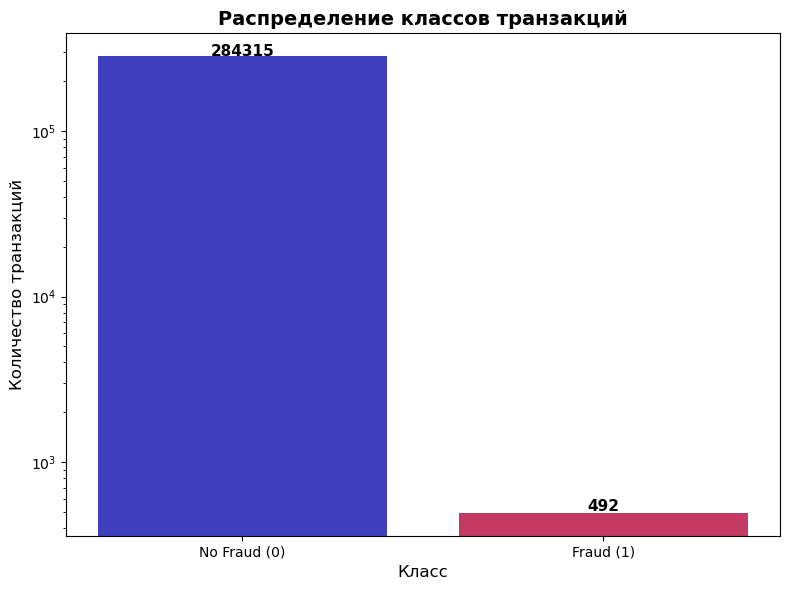

In [5]:
plt.figure(figsize=(8, 6))

counts = df['Class'].value_counts()
labels = ['No Fraud (0)', 'Fraud (1)']
values = counts.values
colors = ['#4040bf', '#c53a63']

plt.bar(labels, values, color=colors)

plt.title('Распределение классов транзакций', fontsize=14, fontweight='bold')
plt.ylabel('Количество транзакций', fontsize=12)
plt.xlabel('Класс', fontsize=12)

for i, v in enumerate(values):
    plt.text(i, v + np.log(max(values)), str(v), ha='center', fontweight='bold', fontsize=11)
    
plt.yscale('log')  
plt.tight_layout()
plt.show()

Посмотрим на распредление признаков. 

Amount имеет хвост вправо, поэтому для начала этот признак нужно прологарифмировать. 

Признак Time имеет синусоидальное распределение, что связано со сменой дня и ночи. 

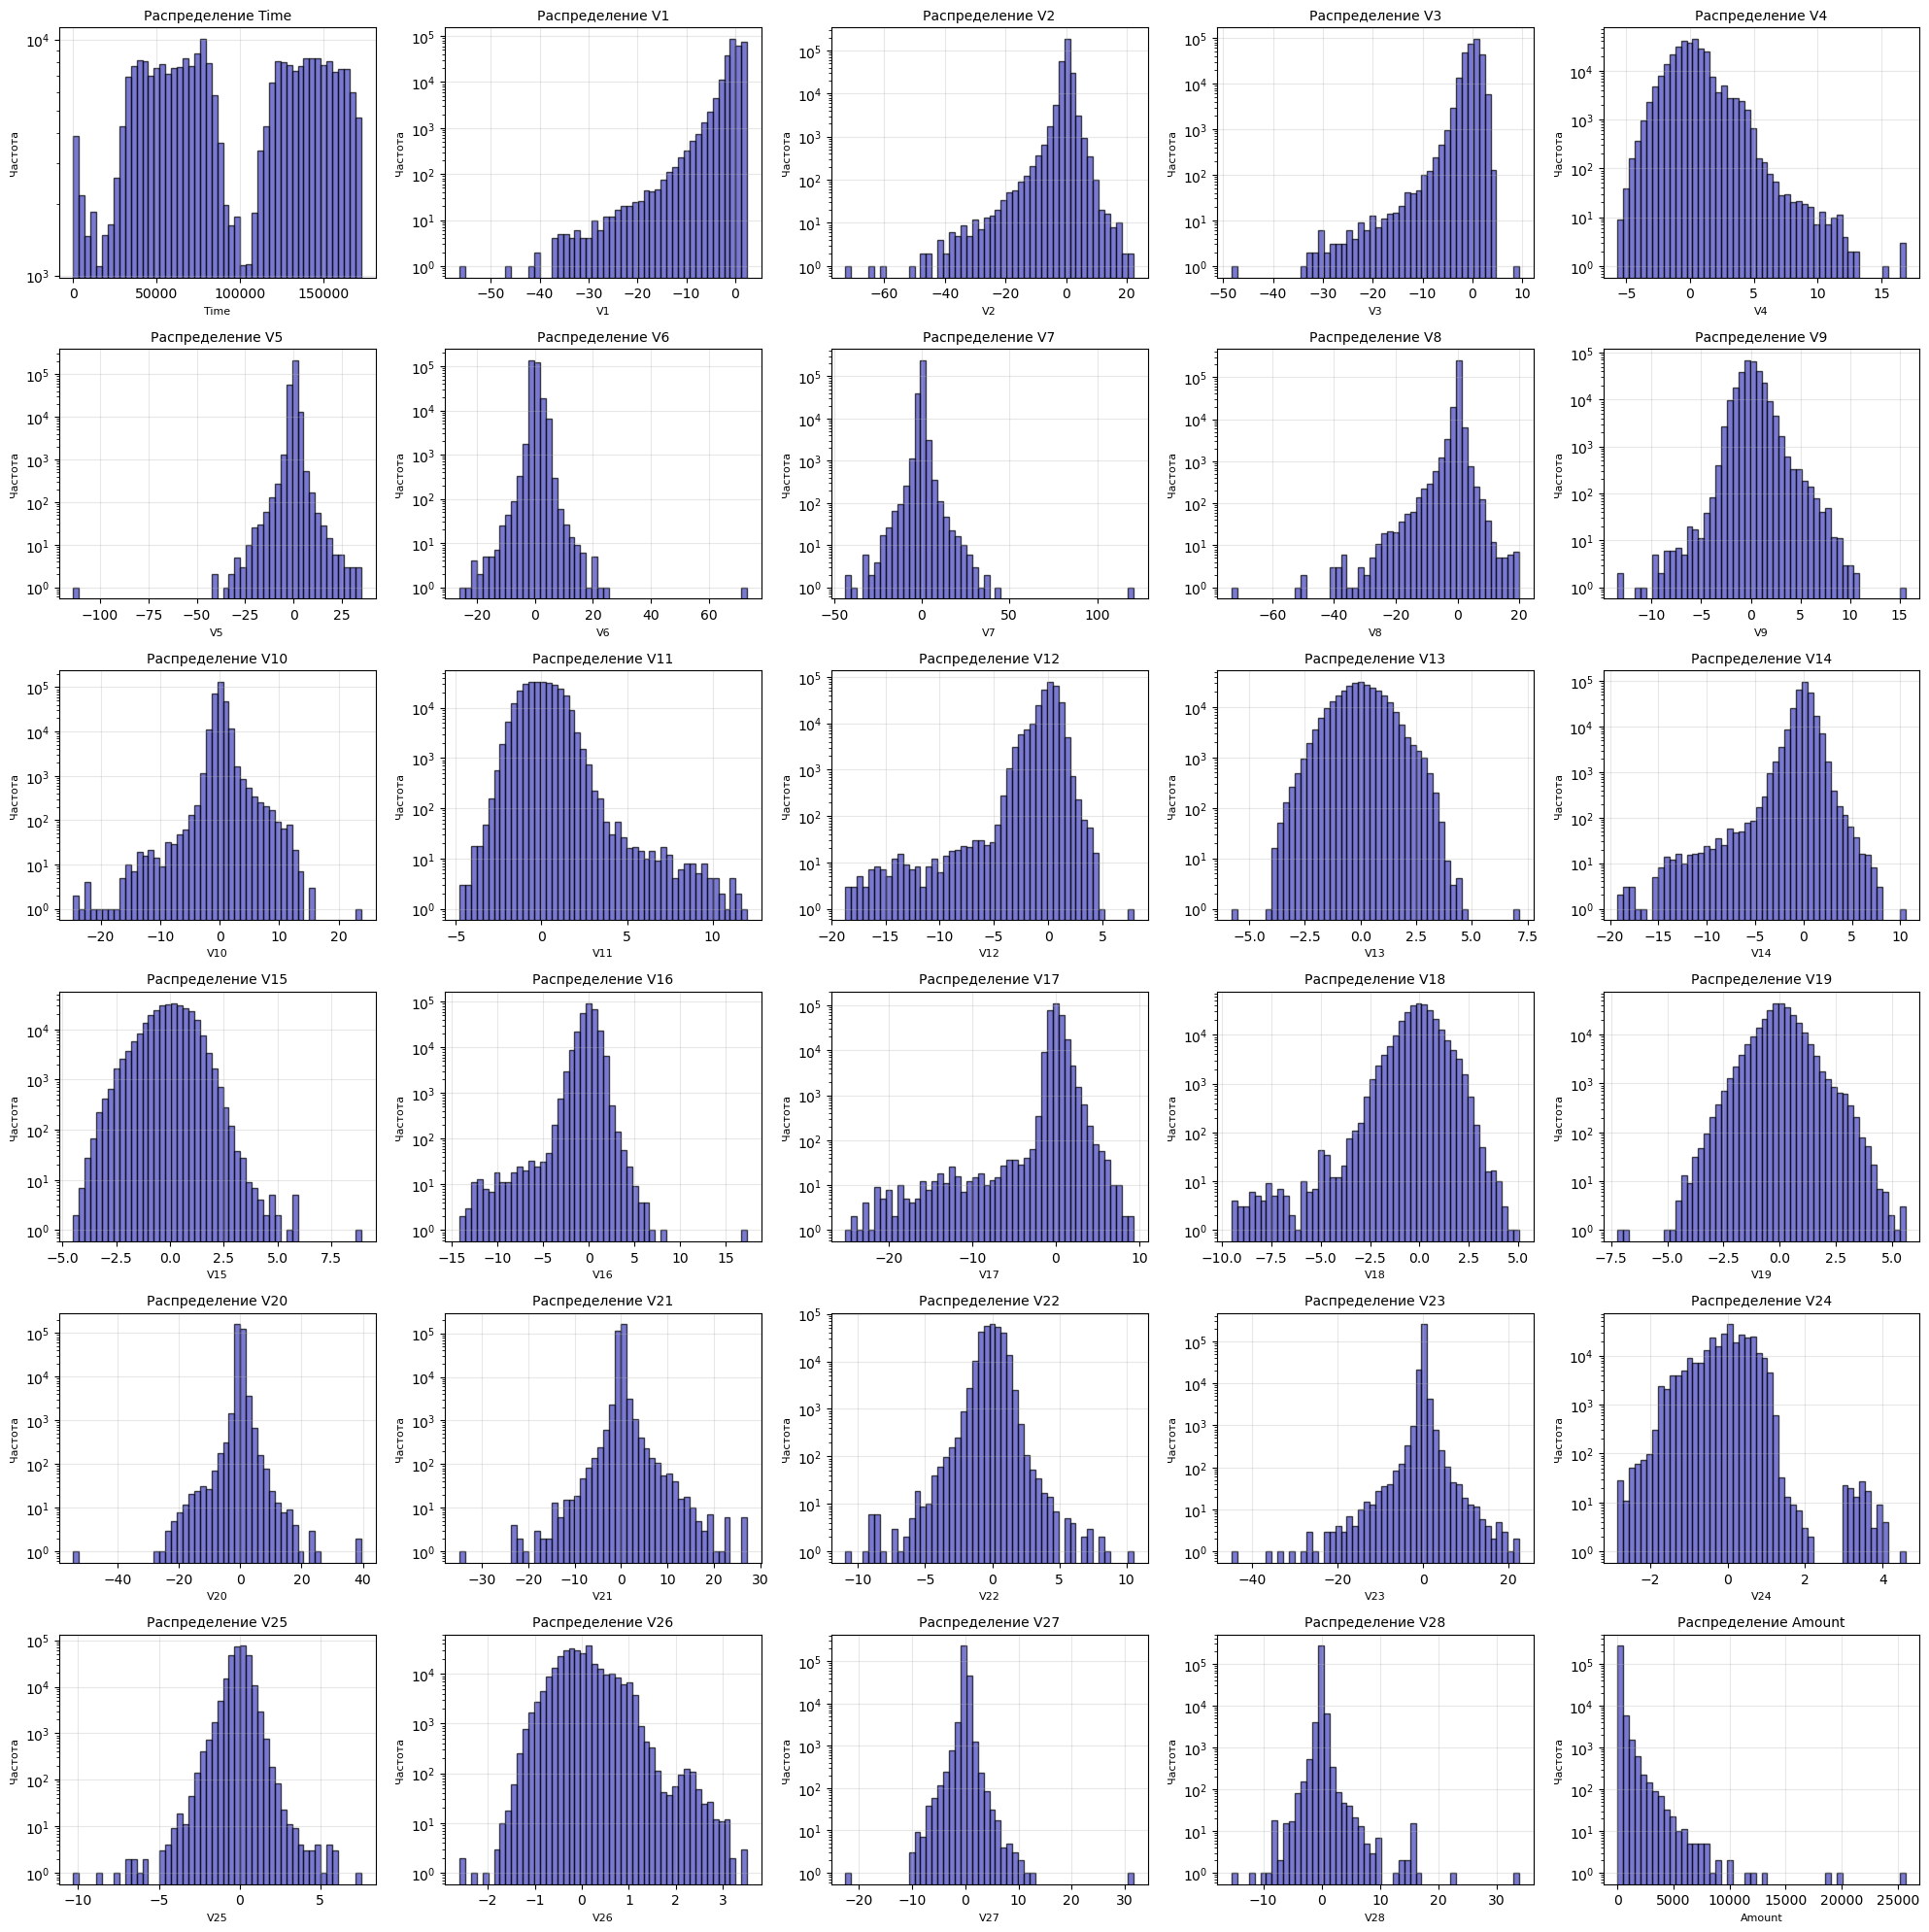

In [6]:
features_all = df.columns.drop('Class').tolist()
n_features = len(features_all)

cols = 5
rows = int(np.ceil(n_features / cols))

plt.figure(figsize=(20, 20))

for i, feature in enumerate(features_all, 1):
    plt.subplot(rows, cols, i)
    plt.hist(df[feature], bins=50, alpha=0.7, color='#4040bf', edgecolor='black')
    plt.title(f'Распределение {feature}', fontsize=10)
    plt.xlabel(feature, fontsize=8)
    plt.ylabel('Частота', fontsize=8)
    plt.grid(alpha=0.3)
    plt.yscale('log')  

plt.tight_layout()
plt.show()

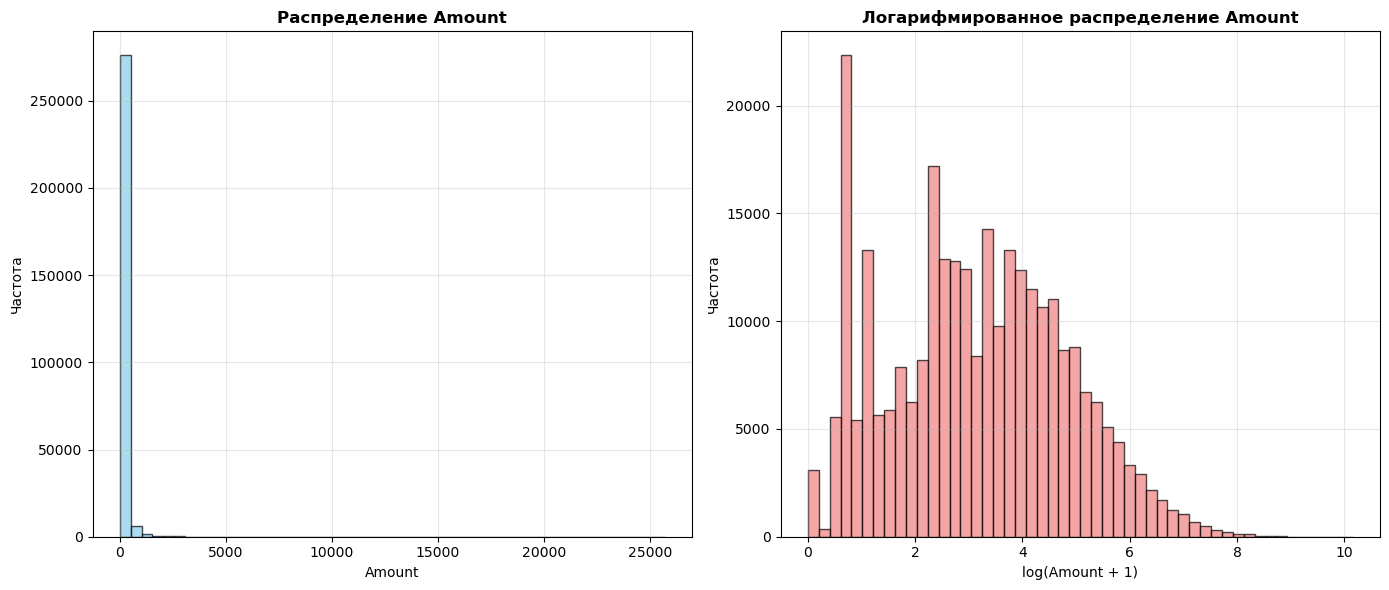

In [7]:
plt.figure(figsize=(14, 6))

df['log_Amount'] = np.log1p(df['Amount']) 

plt.subplot(1, 2, 1)
plt.hist(df['Amount'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Распределение Amount', fontsize=12, fontweight='bold')
plt.xlabel('Amount', fontsize=10)
plt.ylabel('Частота', fontsize=10)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(df['log_Amount'], bins=50, alpha=0.7, color='lightcoral', edgecolor='black')
plt.title('Логарифмированное распределение Amount', fontsize=12, fontweight='bold')
plt.xlabel('log(Amount + 1)', fontsize=10)
plt.ylabel('Частота', fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Маштабируем эти признаки.

In [8]:
robust_scaler = RobustScaler()

df['log_Amount'] = robust_scaler.fit_transform(df['log_Amount'].values.reshape(-1,1))
df['Amount'] = robust_scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['Time'] = robust_scaler.fit_transform(df['Time'].values.reshape(-1,1))

Разделим выборку. 

In [9]:
features = df.columns.drop(['Class', 'Amount']).tolist()

X = df[features]
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [10]:
print("Распределение классов в обучающей выборке:")
print(f"Всего записей: {len(y_train)}")
print(f"Класс 0: {sum(y_train == 0)} ({sum(y_train == 0)/len(y_train)*100:.2f}%)")
print(f"Класс 1: {sum(y_train == 1)} ({sum(y_train == 1)/len(y_train)*100:.2f}%)")

print("\nРаспределение классов в тестовой выборке:")
print(f"Всего записей: {len(y_test)}")
print(f"Класс 0: {sum(y_test == 0)} ({sum(y_test == 0)/len(y_test)*100:.2f}%)")
print(f"Класс 1: {sum(y_test == 1)} ({sum(y_test == 1)/len(y_test)*100:.2f}%)")

Распределение классов в обучающей выборке:
Всего записей: 199364
Класс 0: 199020 (99.83%)
Класс 1: 344 (0.17%)

Распределение классов в тестовой выборке:
Всего записей: 85443
Класс 0: 85295 (99.83%)
Класс 1: 148 (0.17%)


## Построение моделей 

Базовые модели:

- Логистическая регрессия 

- kNN (k-ближайших соседей)

- Решающее дерево

Ансамблевые методы:

- Бэггинг (BaggingClassifier)

- Случайный лес (Random Forest)

- Стекинг (StackingClassifier) для моделей

  *  LogisticRegression,
  *  KNeighborsClassifier,
  *  DecisionTreeClassifier
- Бустинг

In [45]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_pred_proba)
    }
    
    cm = confusion_matrix(y_test, y_pred)
    
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    return metrics, cm, fpr, tpr, roc_auc

def evaluate_model_new_threshold(model, threshold, X_train, X_test, y_train, y_test, model_name):
    model.fit(X_train, y_train)
    
    y_pred = (model.predict_proba(X_test)[:,1] > threshold).astype(int)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_pred_proba)
    }
    
    cm = confusion_matrix(y_test, y_pred)
    
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    return metrics, cm, fpr, tpr, roc_auc
    
def plot_confusion_matrix(cm, model_name):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Normal', 'Fraud'], 
                yticklabels=['Normal', 'Fraud'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

def plot_roc_curve(fpr, tpr, roc_auc, model_name):
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, 
             label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {model_name}')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.show()

### Базовые модели

#### Логистическая регрессия 

In [13]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],  
    'penalty': ['l1', 'l2'],
    'class_weight': [None, 'balanced']
}

grid_lr = GridSearchCV(
    LogisticRegression(random_state=42, solver='liblinear'),
    param_grid_lr,
    cv=skf,
    scoring='roc_auc',
    n_jobs=6,
    verbose=1
)

grid_lr.fit(X_train, y_train)

print(f"Лучшие параметры: {grid_lr.best_params_}")
print(f"Лучший ROC-AUC (CV): {grid_lr.best_score_:.4f}")

lr_best = grid_lr.best_estimator_

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Лучшие параметры: {'C': 0.01, 'class_weight': None, 'penalty': 'l2'}
Лучший ROC-AUC (CV): 0.9859


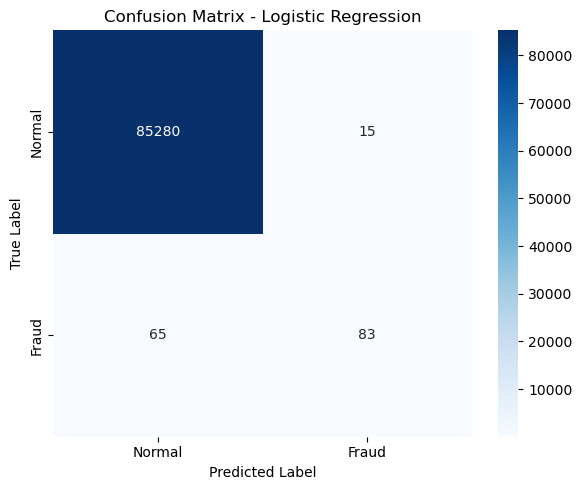

In [44]:
lr_metrics, lr_cm, lr_fpr, lr_tpr, lr_auc = evaluate_model(
    lr_best, X_train, X_test, y_train, y_test, "Logistic Regression"
)

plot_confusion_matrix(lr_cm, "Logistic Regression")

Подберем оптимальный порог по F1-score.

In [19]:
thresholds_lr = []
thr_grid = np.linspace(0.01, 0.99, 99)

for train_idx, val_idx in skf.split(X_train, y_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    model = clone(lr_best)
    model.fit(X_tr, y_tr)

    proba_val = model.predict_proba(X_val)[:, 1]
    f1s = [f1_score(y_val, (proba_val > t).astype(int), zero_division=0) for t in thr_grid]
    best_t = thr_grid[np.argmax(f1s)]
    thresholds_lr.append(best_t)

final_threshold_lr = float(np.median(thresholds_lr))
print("Threshold на каждом фолде:", thresholds_lr)
print("Оптимальный threshold:", final_threshold_lr)

Threshold на каждом фолде: [np.float64(0.15000000000000002), np.float64(0.12), np.float64(0.13), np.float64(0.13), np.float64(0.16)]
Оптимальный threshold: 0.13


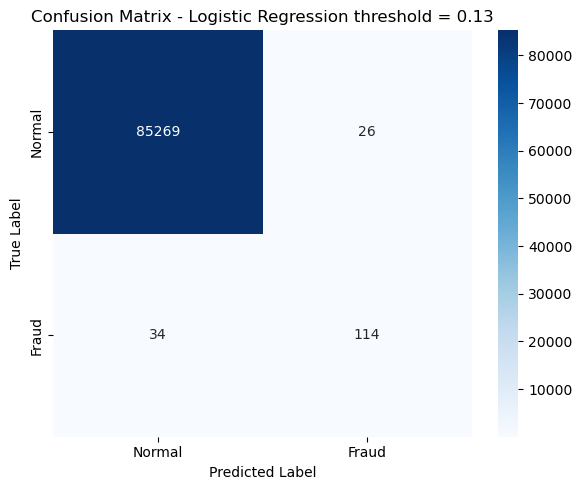

In [46]:
lr_metrics_tr, lr_cm_tr, lr_fpr_tr, lr_tpr_tr, lr_auc_tr = evaluate_model_new_threshold(
    lr_best, final_threshold_lr, X_train, X_test, y_train, y_test, "Logistic Regression threshold = 0.13"
)

plot_confusion_matrix(lr_cm_tr, "Logistic Regression threshold = 0.13")

#### kNN

In [27]:
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance']
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=skf,
    scoring='roc_auc',
    n_jobs=6,
    verbose=1
)

grid_knn.fit(X_train, y_train)

print(f"Лучшие параметры: {grid_knn.best_params_}")
print(f"Лучший ROC-AUC (CV): {grid_knn.best_score_:.4f}")

knn_best = grid_knn.best_estimator_

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Лучшие параметры: {'n_neighbors': 11, 'weights': 'distance'}
Лучший ROC-AUC (CV): 0.9271


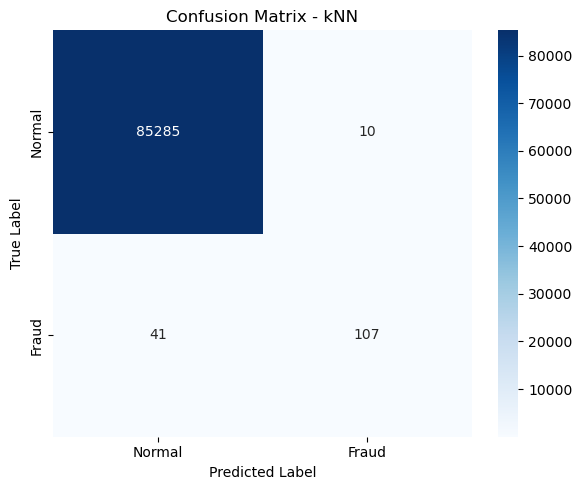

In [48]:
knn_metrics, knn_cm, knn_fpr, knn_tpr, knn_auc = evaluate_model(
    knn_best, X_train, X_test, y_train, y_test, "kNN"
)

plot_confusion_matrix(knn_cm, "kNN")

In [28]:
thresholds_knn = []
thr_grid = np.linspace(0.01, 0.99, 99)

for train_idx, val_idx in skf.split(X_train, y_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    model = clone(knn_best)
    model.fit(X_tr, y_tr)

    proba_val = model.predict_proba(X_val)[:, 1]
    f1s = [f1_score(y_val, (proba_val > t).astype(int), zero_division=0) for t in thr_grid]
    best_t = thr_grid[np.argmax(f1s)]
    thresholds_knn.append(best_t)

final_threshold_knn = float(np.median(thresholds_knn))
print("Threshold на каждом фолде:", thresholds_knn)
print("Оптимальный threshold:", final_threshold_knn)

Threshold на каждом фолде: [np.float64(0.62), np.float64(0.38), np.float64(0.67), np.float64(0.29000000000000004), np.float64(0.28)]
Оптимальный threshold: 0.38


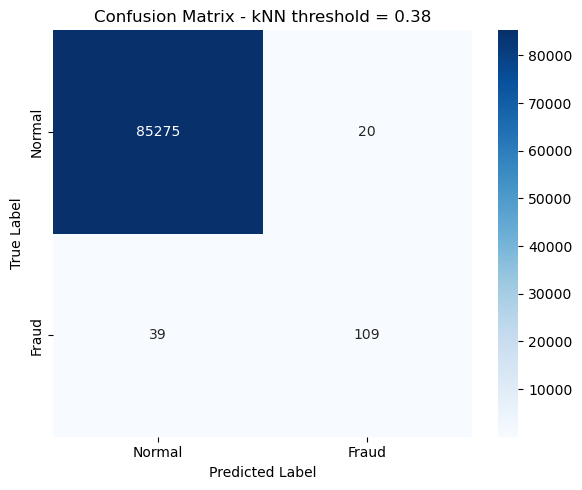

In [49]:
knn_metrics_tr, knn_cm_tr, knn_fpr_tr, knn_tpr_tr, knn_auc_tr = evaluate_model_new_threshold(
    knn_best, final_threshold_knn, X_train, X_test, y_train, y_test, "kNN threshold = 0.38"
)

plot_confusion_matrix(knn_cm_tr, "kNN threshold = 0.38")

#### Решающее дерево

In [29]:
param_grid_dt = {
    'max_depth': [3, 5, 7, 9, 11],
    'min_samples_leaf': [1, 2, 3, 4, 5],
    'min_samples_split' : [2, 4, 6, 8, 10],
    'class_weight': [None, 'balanced']
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=skf,
    scoring='roc_auc',
    n_jobs=6,
    verbose=1
)

grid_dt.fit(X_train, y_train)

print(f"Лучшие параметры: {grid_dt.best_params_}")
print(f"Лучший ROC-AUC (CV): {grid_dt.best_score_:.4f}")

dt_best = grid_dt.best_estimator_

Fitting 5 folds for each of 250 candidates, totalling 1250 fits
Лучшие параметры: {'class_weight': 'balanced', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Лучший ROC-AUC (CV): 0.9504


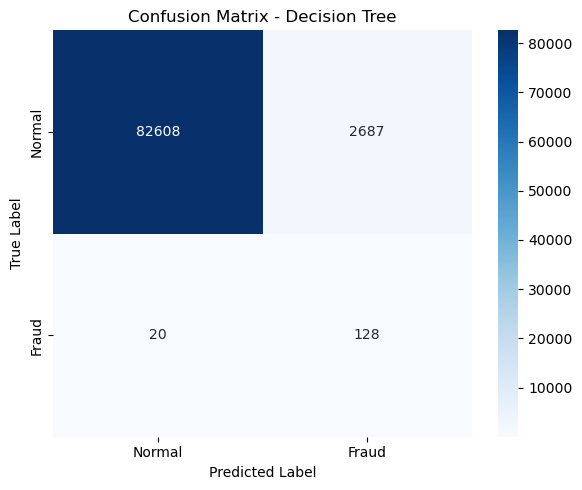

In [50]:
dt_metrics, dt_cm, dt_fpr, dt_tpr, dt_auc = evaluate_model(
    dt_best, X_train, X_test, y_train, y_test, "Decision Tree"
)
plot_confusion_matrix(dt_cm, "Decision Tree")

In [30]:
thresholds_dt = []
thr_grid = np.linspace(0.01, 0.99, 99)

for train_idx, val_idx in skf.split(X_train, y_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    model = clone(dt_best)
    model.fit(X_tr, y_tr)

    proba_val = model.predict_proba(X_val)[:, 1]
    f1s = [f1_score(y_val, (proba_val > t).astype(int), zero_division=0) for t in thr_grid]
    best_t = thr_grid[np.argmax(f1s)]
    thresholds_dt.append(best_t)

final_threshold_dt = float(np.median(thresholds_dt))
print("Threshold на каждом фолде:", thresholds_dt)
print("Оптимальный threshold:", final_threshold_dt)

Threshold на каждом фолде: [np.float64(0.93), np.float64(0.9500000000000001), np.float64(0.8300000000000001), np.float64(0.79), np.float64(0.8200000000000001)]
Оптимальный threshold: 0.8300000000000001


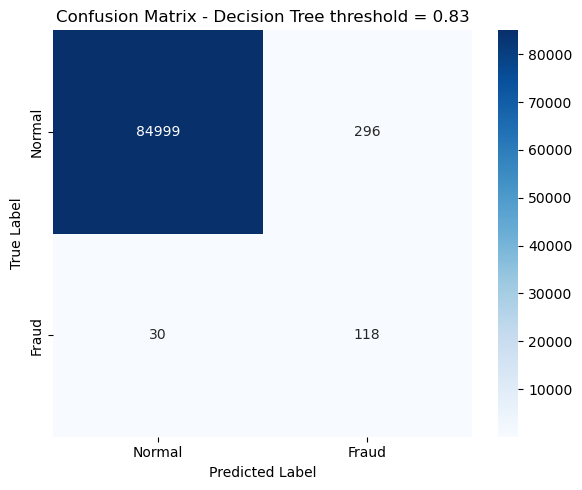

In [51]:
dt_metrics_tr, dt_cm_tr, dt_fpr_tr, dt_tpr_tr, dt_auc_tr = evaluate_model_new_threshold(
    dt_best, final_threshold_dt, X_train, X_test, y_train, y_test, "Decision Tree threshold = 0.83"
)

plot_confusion_matrix(dt_cm_tr, "Decision Tree threshold = 0.83")

### Ансамблевые методы

#### Бэггинг

В качестве базового классификатора возьмем оптимальную модель дерева, полученную ранее. 

In [31]:
base_dt = DecisionTreeClassifier(
    class_weight='balanced',
    max_depth=3,
    min_samples_leaf=1,
    min_samples_split=2,
    random_state=42  
)

param_grid_bag = {
    'n_estimators': [50, 100, 150, 200],
    'max_samples': [0.5, 0.7, 1.0]
}

grid_bag = GridSearchCV(
    BaggingClassifier(estimator=base_dt, random_state=42, n_jobs=6),
    param_grid_bag,
    cv=skf,
    scoring='roc_auc',
    n_jobs=6,
    verbose=0
)

grid_bag.fit(X_train, y_train)

print(f"Лучшие параметры: {grid_bag.best_params_}")
print(f"Лучший ROC-AUC (CV): {grid_bag.best_score_:.4f}")

bag_best = grid_bag.best_estimator_

Лучшие параметры: {'max_samples': 0.5, 'n_estimators': 200}
Лучший ROC-AUC (CV): 0.9809


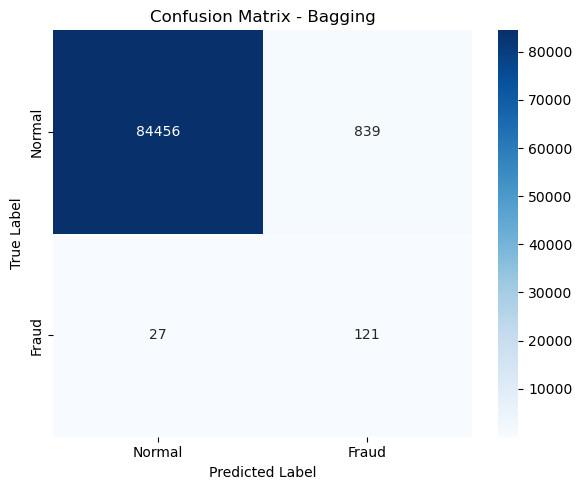

In [52]:
bag_metrics, bag_cm, bag_fpr, bag_tpr, bag_auc = evaluate_model(
    bag_best, X_train, X_test, y_train, y_test, "Bagging"
)

plot_confusion_matrix(bag_cm, "Bagging")

In [32]:
thresholds_bag = []
thr_grid = np.linspace(0.01, 0.99, 99)

for train_idx, val_idx in skf.split(X_train, y_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    model = clone(bag_best)
    model.fit(X_tr, y_tr)

    proba_val = model.predict_proba(X_val)[:, 1]
    f1s = [f1_score(y_val, (proba_val > t).astype(int), zero_division=0) for t in thr_grid]
    best_t = thr_grid[np.argmax(f1s)]
    thresholds_bag.append(best_t)

final_threshold_bag = float(np.median(thresholds_bag))
print("Threshold на каждом фолде:", thresholds_bag)
print("Оптимальный threshold:", final_threshold_bag)

Threshold на каждом фолде: [np.float64(0.9), np.float64(0.88), np.float64(0.9), np.float64(0.87), np.float64(0.9400000000000001)]
Оптимальный threshold: 0.9


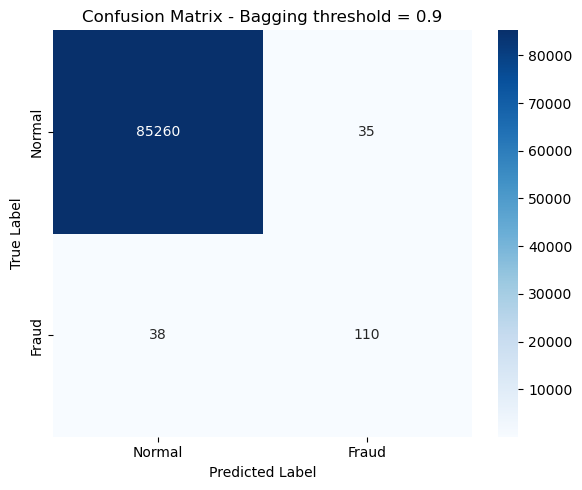

In [53]:
bag_metrics_tr, bag_cm_tr, bag_fpr_tr, bag_tpr_tr, bag_auc_tr = evaluate_model_new_threshold(
    bag_best, final_threshold_bag, X_train, X_test, y_train, y_test, "Bagging threshold = 0.9"
)

plot_confusion_matrix(bag_cm_tr, "Bagging threshold = 0.9")

#### Случайный лес

In [34]:
param_grid_rf = {
    'n_estimators': [50, 100, 150, 200],
    'max_samples': [0.5, 0.7, 1.0],
    'max_depth': [3, 5, 7, 10],
    'class_weight': [None, 'balanced']
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=6),
    param_grid_rf,
    cv=skf,
    scoring='roc_auc',
    n_jobs=6,
    verbose=0
)

grid_rf.fit(X_train, y_train)

print(f"Лучшие параметры: {grid_rf.best_params_}")
print(f"Лучший ROC-AUC (CV): {grid_rf.best_score_:.4f}")

rf_best = grid_rf.best_estimator_

Лучшие параметры: {'class_weight': 'balanced', 'max_depth': 5, 'max_samples': 0.5, 'n_estimators': 150}
Лучший ROC-AUC (CV): 0.9820


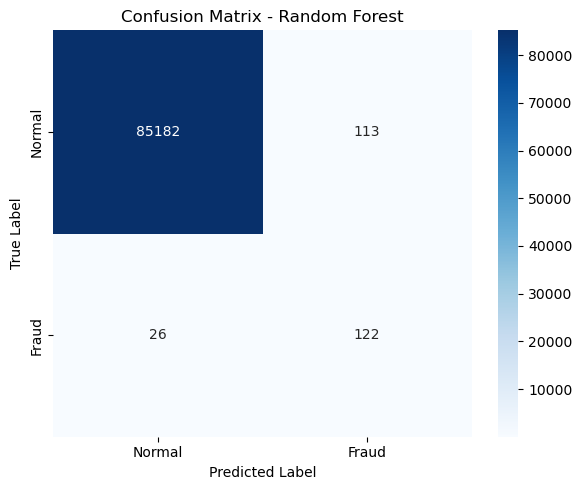

In [54]:
rf_metrics, rf_cm, rf_fpr, rf_tpr, rf_auc = evaluate_model(
    rf_best, X_train, X_test, y_train, y_test, "Random Forest"
)

plot_confusion_matrix(rf_cm, "Random Forest")

In [35]:
thresholds_rf = []
thr_grid = np.linspace(0.01, 0.99, 99)

for train_idx, val_idx in skf.split(X_train, y_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    model = clone(rf_best)
    model.fit(X_tr, y_tr)

    proba_val = model.predict_proba(X_val)[:, 1]
    f1s = [f1_score(y_val, (proba_val > t).astype(int), zero_division=0) for t in thr_grid]
    best_t = thr_grid[np.argmax(f1s)]
    thresholds_rf.append(best_t)

final_threshold_rf = float(np.median(thresholds_rf))
print("Threshold на каждом фолде:", thresholds_rf)
print("Оптимальный threshold:", final_threshold_rf)

Threshold на каждом фолде: [np.float64(0.62), np.float64(0.61), np.float64(0.65), np.float64(0.63), np.float64(0.7100000000000001)]
Оптимальный threshold: 0.63


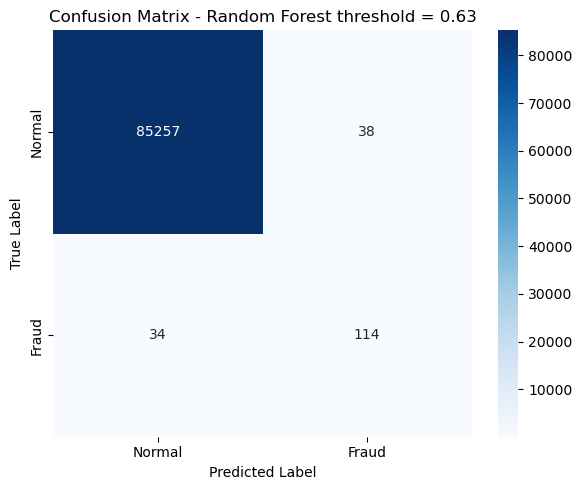

In [55]:
rf_metrics_tr, rf_cm_tr, rf_fpr_tr, rf_tpr_tr, rf_auc_tr = evaluate_model_new_threshold(
    rf_best, final_threshold_rf, X_train, X_test, y_train, y_test, "Random Forest threshold = 0.63"
)

plot_confusion_matrix(rf_cm_tr, "Random Forest threshold = 0.63")

#### Стекинг 

In [36]:
estimators = [
    ('lr', LogisticRegression(
        C=0.01, 
        penalty='l2', 
        solver='liblinear',
        class_weight=None,
        random_state=42
    )),
    ('knn', KNeighborsClassifier(
        n_neighbors=11,
        weights='distance'
    )),
    ('dt', DecisionTreeClassifier(
        max_depth=3,
        min_samples_leaf=1,
        min_samples_split=2,
        class_weight='balanced',
        random_state=42
    ))
]


param_grid_stack = {
    'final_estimator': [
        LogisticRegression(random_state=42),
        RandomForestClassifier(n_estimators=100, random_state=42)
    ],
    'passthrough': [True, False]
}

grid_stack = GridSearchCV(
    StackingClassifier(estimators=estimators, cv=skf, n_jobs=6),
    param_grid_stack,
    cv=skf,
    scoring='roc_auc',
    n_jobs=6,
    verbose=0
)

grid_stack.fit(X_train, y_train)

print(f"Лучшие параметры: {grid_stack.best_params_}")
print(f"Лучший ROC-AUC (CV): {grid_stack.best_score_:.4f}")

stack_best = grid_stack.best_estimator_

Лучшие параметры: {'final_estimator': LogisticRegression(random_state=42), 'passthrough': True}
Лучший ROC-AUC (CV): 0.9783


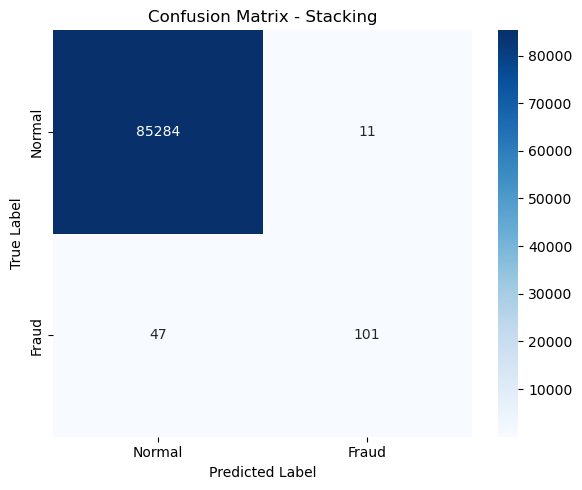

In [56]:
stack_metrics, stack_cm, stack_fpr, stack_tpr, stack_auc = evaluate_model(
    stack_best, X_train, X_test, y_train, y_test, "Stacking"
)

plot_confusion_matrix(stack_cm, "Stacking")

In [37]:
thresholds_stack = []
thr_grid = np.linspace(0.01, 0.99, 99)

for train_idx, val_idx in skf.split(X_train, y_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    model = clone(stack_best)
    model.fit(X_tr, y_tr)

    proba_val = model.predict_proba(X_val)[:, 1]
    f1s = [f1_score(y_val, (proba_val > t).astype(int), zero_division=0) for t in thr_grid]
    best_t = thr_grid[np.argmax(f1s)]
    thresholds_stack.append(best_t)

final_threshold_stack = float(np.median(thresholds_stack))
print("Threshold на каждом фолде:", thresholds_stack)
print("Оптимальный threshold:", final_threshold_stack)

Threshold на каждом фолде: [np.float64(0.28), np.float64(0.56), np.float64(0.39), np.float64(0.45), np.float64(0.35000000000000003)]
Оптимальный threshold: 0.39


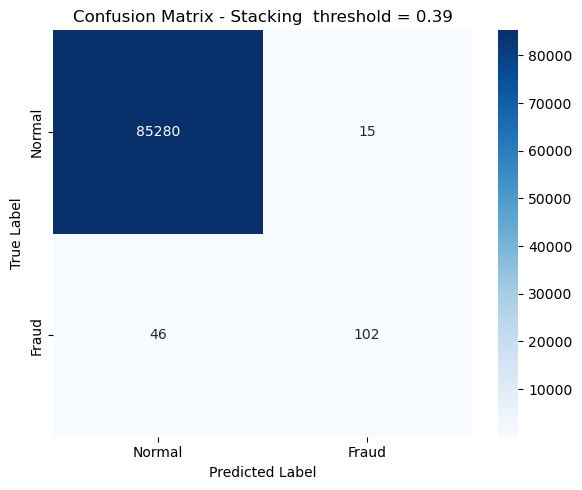

In [57]:
stack_metrics_tr, stack_cm_tr, stack_fpr_tr, stack_tpr_tr, stack_auc_tr = evaluate_model_new_threshold(
    stack_best, final_threshold_stack, X_train, X_test, y_train, y_test, "Stacking  threshold = 0.39"
)

plot_confusion_matrix(stack_cm_tr, "Stacking  threshold = 0.39")

#### Бустинг

In [41]:
lgb_clf = lgb.LGBMClassifier(
    objective='binary',
    boosting_type='gbdt',
    random_state=42,
    n_jobs=6
)


param_grid_lgb = {
    'n_estimators': [50, 100],
    'class_weight': [None, 'balanced'],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [15, 31],
    'max_depth': [-1, 5],
    'min_child_samples': [20, 50],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}


grid_lgb = GridSearchCV(
    estimator=lgb_clf,
    param_grid=param_grid_lgb,
    cv=skf,
    scoring='roc_auc',
    n_jobs=6,
    verbose=1
)

grid_lgb.fit(X_train, y_train)

print(f"Лучшие параметры: {grid_lgb.best_params_}")
print(f"Лучший ROC-AUC (CV): {grid_lgb.best_score_:.4f}")

lgb_best = grid_lgb.best_estimator_

Fitting 5 folds for each of 384 candidates, totalling 1920 fits
[LightGBM] [Info] Number of positive: 344, number of negative: 199020
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.013945 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 199364, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Лучшие параметры: {'class_weight': 'balanced', 'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'min_child_samples': 20, 'n_estimators': 50, 'num_leaves': 15, 'subsample': 0.8}
Лучший ROC-AUC (CV): 0.9799


[LightGBM] [Info] Number of positive: 344, number of negative: 199020
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.013490 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 199364, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


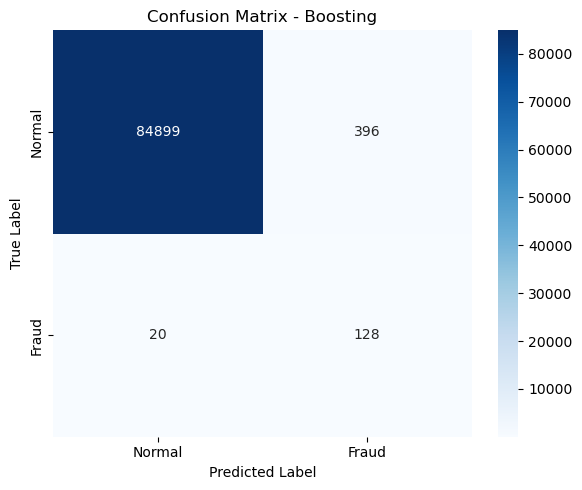

In [58]:
lgb_metrics, lgb_cm, lgb_fpr, lgb_tpr, lgb_auc = evaluate_model(
    lgb_best, X_train, X_test, y_train, y_test, "Boosting"
)

plot_confusion_matrix(lgb_cm, "Boosting")

In [42]:
thresholds_lgb = []
thr_grid = np.linspace(0.01, 0.99, 99)

for train_idx, val_idx in skf.split(X_train, y_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    model = clone(lgb_best)
    model.fit(X_tr, y_tr)

    proba_val = model.predict_proba(X_val)[:, 1]
    f1s = [f1_score(y_val, (proba_val > t).astype(int), zero_division=0) for t in thr_grid]
    best_t = thr_grid[np.argmax(f1s)]
    thresholds_lgb.append(best_t)

final_threshold_lgb = float(np.median(thresholds_lgb))
print("Threshold на каждом фолде:", thresholds_lgb)
print("Оптимальный threshold:", final_threshold_lgb)

[LightGBM] [Info] Number of positive: 275, number of negative: 159216
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011346 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 159491, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Info] Number of positive: 275, number of negative: 159216
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010920 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 159491, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Info

[LightGBM] [Info] Number of positive: 344, number of negative: 199020
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.013373 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 199364, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


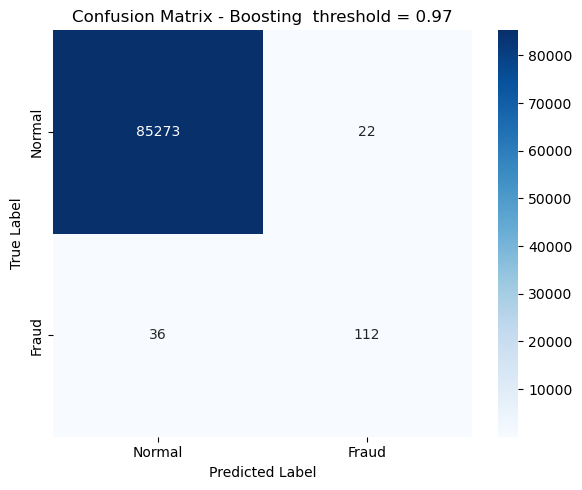

In [59]:
lgb_metrics_tr, lgb_cm_tr, lgb_fpr_tr, lgb_tpr_tr, lgb_auc_tr = evaluate_model_new_threshold(
    lgb_best, final_threshold_lgb, X_train, X_test, y_train, y_test, "Boosting  threshold = 0.97"
)

plot_confusion_matrix(lgb_cm_tr, "Boosting  threshold = 0.97")

## Сравнительный анализ моделей

- По метрике F1-Score ***наилучшее качество показывает kNN***
- Модели с высоким Recall: Boosting, Decision Tree, Bagging, Random Forest
- Модели с высоким Precision: kNN, Staking, Staking tr, Logistic Regression, kNN tr
- По AUC лучшими моделями являются Random Forest, Logistic Regression, Bagging

In [91]:
models_metrics = {
    'Logistic Regression': {
        'Accuracy':  lr_metrics['Accuracy'],
        'Precision': lr_metrics['Precision'],
        'Recall': lr_metrics['Recall'], 
        'F1-Score': lr_metrics['F1-Score'],
        'ROC-AUC': lr_metrics['ROC-AUC']
    },
    'Logistic Regression tr': {
        'Accuracy':  lr_metrics_tr['Accuracy'],
        'Precision': lr_metrics_tr['Precision'],
        'Recall': lr_metrics_tr['Recall'], 
        'F1-Score': lr_metrics_tr['F1-Score'],
        'ROC-AUC': lr_metrics_tr['ROC-AUC']
    },
    'kNN': {
        'Accuracy':  knn_metrics['Accuracy'],
        'Precision': knn_metrics['Precision'],
        'Recall': knn_metrics['Recall'],
        'F1-Score': knn_metrics['F1-Score'],
        'ROC-AUC': knn_metrics['ROC-AUC']
    },
    'kNN tr': {
        'Accuracy':  knn_metrics_tr['Accuracy'],
        'Precision': knn_metrics_tr['Precision'],
        'Recall': knn_metrics_tr['Recall'],
        'F1-Score': knn_metrics_tr['F1-Score'],
        'ROC-AUC': knn_metrics_tr['ROC-AUC']
    },
    'Decision Tree': {
        'Accuracy':  dt_metrics['Accuracy'],
        'Precision': dt_metrics['Precision'],
        'Recall': dt_metrics['Recall'],
        'F1-Score': dt_metrics['F1-Score'],
        'ROC-AUC': dt_metrics['ROC-AUC']
    },
    'Decision Tree tr': {
        'Accuracy':  dt_metrics_tr['Accuracy'],
        'Precision': dt_metrics_tr['Precision'],
        'Recall': dt_metrics_tr['Recall'],
        'F1-Score': dt_metrics_tr['F1-Score'],
        'ROC-AUC': dt_metrics_tr['ROC-AUC']
    },
    'Bagging': {
        'Accuracy':  bag_metrics['Accuracy'],
        'Precision': bag_metrics['Precision'],
        'Recall': bag_metrics['Recall'],
        'F1-Score': bag_metrics['F1-Score'],
        'ROC-AUC': bag_metrics['ROC-AUC']
    },
    'Bagging tr': {
        'Accuracy':  bag_metrics_tr['Accuracy'],
        'Precision': bag_metrics_tr['Precision'],
        'Recall': bag_metrics_tr['Recall'],
        'F1-Score': bag_metrics_tr['F1-Score'],
        'ROC-AUC': bag_metrics_tr['ROC-AUC']
    },
    'Random Forest': {
        'Accuracy':  rf_metrics['Accuracy'],
        'Precision': rf_metrics['Precision'],
        'Recall': rf_metrics['Recall'],
        'F1-Score': rf_metrics['F1-Score'],
        'ROC-AUC': rf_metrics['ROC-AUC']
    },
    'Random Forest tr': {
        'Accuracy':  rf_metrics_tr['Accuracy'],
        'Precision': rf_metrics_tr['Precision'],
        'Recall': rf_metrics_tr['Recall'],
        'F1-Score': rf_metrics_tr['F1-Score'],
        'ROC-AUC': rf_metrics_tr['ROC-AUC']
    },
    'Stacking': {
        'Accuracy':  stack_metrics['Accuracy'],
        'Precision': stack_metrics['Precision'],
        'Recall': stack_metrics['Recall'],
        'F1-Score': stack_metrics['F1-Score'],
        'ROC-AUC': stack_metrics['ROC-AUC']
    }, 
    'Stacking tr': {
        'Accuracy':  stack_metrics_tr['Accuracy'],
        'Precision': stack_metrics_tr['Precision'],
        'Recall': stack_metrics_tr['Recall'],
        'F1-Score': stack_metrics_tr['F1-Score'],
        'ROC-AUC': stack_metrics_tr['ROC-AUC']
    },
    'Boosting': {
        'Accuracy':  lgb_metrics['Accuracy'],
        'Precision': lgb_metrics['Precision'],
        'Recall': lgb_metrics['Recall'],
        'F1-Score': lgb_metrics['F1-Score'],
        'ROC-AUC': lgb_metrics['ROC-AUC']
    }, 
    'Boosting tr': {
        'Accuracy':  lgb_metrics_tr['Accuracy'],
        'Precision': lgb_metrics_tr['Precision'],
        'Recall': lgb_metrics_tr['Recall'],
        'F1-Score': lgb_metrics_tr['F1-Score'],
        'ROC-AUC': lgb_metrics_tr['ROC-AUC']
    }
}


comparison_df = pd.DataFrame(models_metrics).T

column_order = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
comparison_df = comparison_df[column_order]

comparison_df = comparison_df.sort_values('F1-Score', ascending=False)

print("Сравнение моделей (отсортировано по F1-Score):")
comparison_df

Сравнение моделей (отсортировано по F1-Score):


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
kNN,0.999403,0.914530,0.722973,0.807547,0.922093
Boosting tr,0.999321,0.835821,0.756757,0.794326,0.964631
Logistic Regression tr,0.999298,0.814286,0.770270,0.791667,0.969643
kNN tr,0.999309,0.844961,0.736486,0.787004,0.922093
Stacking,0.999321,0.901786,0.682432,0.776923,0.953690
Stacking tr,0.999286,0.871795,0.689189,0.769811,0.953690
Random Forest tr,0.999157,0.750000,0.770270,0.760000,0.976918
Bagging tr,0.999146,0.758621,0.743243,0.750853,0.968603
Logistic Regression,0.999064,0.846939,0.560811,0.674797,0.969643
Random Forest,0.998373,0.519149,0.824324,0.637076,0.976918


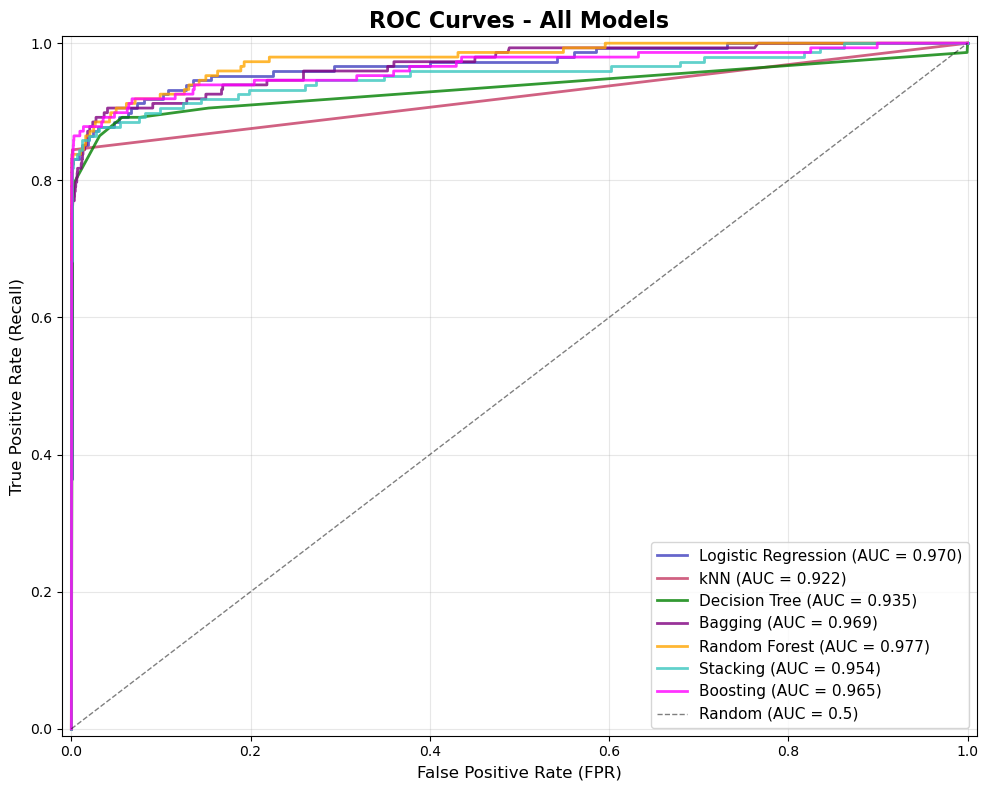

In [61]:
plt.figure(figsize=(10, 8))

colors = ['#4040bf', '#c53a63', 'green', 'purple', 'orange', '#39c6bf', 'magenta']

models_data = [
    ('Logistic Regression', lr_fpr, lr_tpr, lr_auc, colors[0]),
    ('kNN', knn_fpr, knn_tpr, knn_auc, colors[1]),
    ('Decision Tree', dt_fpr, dt_tpr, dt_auc, colors[2]),
    ('Bagging', bag_fpr, bag_tpr, bag_auc, colors[3]),
    ('Random Forest', rf_fpr, rf_tpr, rf_auc, colors[4]),
    ('Stacking', stack_fpr, stack_tpr, stack_auc, colors[5]),
    ('Boosting', lgb_fpr, lgb_tpr, lgb_auc, colors[6])
]

for model_name, fpr, tpr, auc_val, color in models_data:
    plt.plot(fpr, tpr, color=color, lw=2, alpha=0.8, 
             label=f'{model_name} (AUC = {auc_val:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random (AUC = 0.5)')

plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curves - All Models', fontsize=16, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Анализ лучшей модели

In [63]:
y_pred_proba_best = knn_best.predict_proba(X_test)[:, 1]
y_pred_best = knn_best.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
tn, fp, fn, tp = cm.ravel()

print(f"\nМатрица ошибок:")
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")

print(f"\nДоля ошибок:")
print(f"FPR (False Positive Rate): {fp/(fp+tn):.4f}")
print(f"FNR (False Negative Rate): {fn/(fn+tp):.4f}")


Матрица ошибок:
True Negatives (TN): 85285
False Positives (FP): 10
False Negatives (FN): 41
True Positives (TP): 107

Доля ошибок:
FPR (False Positive Rate): 0.0001
FNR (False Negative Rate): 0.2770


- FPR = 0.0001 (0.01%) --- очень низкий показатель. Эта модель имеет 10 ложных срабатываний из 85295 нормальных транзакций.

- FNR = 0.277 (27.7%) --- относительно высокий показатель, модель имеет 41 пропущенную мошенническую транзакцию из 148. То есть на практике из 10 мошеннических транзакций пропускается ~3.

In [64]:
X_test_err = X_test.copy()
X_test_err['y_true'] = y_test.values
X_test_err['y_pred'] = y_pred_best
X_test_err['error_type'] = 'correct'

X_test_err.loc[
    (X_test_err['y_true'] == 0) & (X_test_err['y_pred'] == 1),
    'error_type'
] = 'FP' # называем обычного человека  мошенником

X_test_err.loc[
    (X_test_err['y_true'] == 1) & (X_test_err['y_pred'] == 0),
    'error_type'
] = 'FN' # называем мошенника обычным человеком 

**Анализ распределения ошибок по Amount**

- **FN**: Среднее значение --- **наибольшее среди всех групп**. Это означает, что модель чаще пропускает мошеннические операции (FN) при **более высоких суммах транзакций**.
- **FP**: Среднее --- **наименьшее среди всех**. Модель чаще ложно классифицирует как мошенничество (FP) **транзакции с меньшими суммами**.

**Вывод**: Модель имеет **систематическую ошибку** --- склонна считать крупные транзакции легитимными (пропускает мошенничество), а мелкие --- подозрительными (ложные срабатывания).

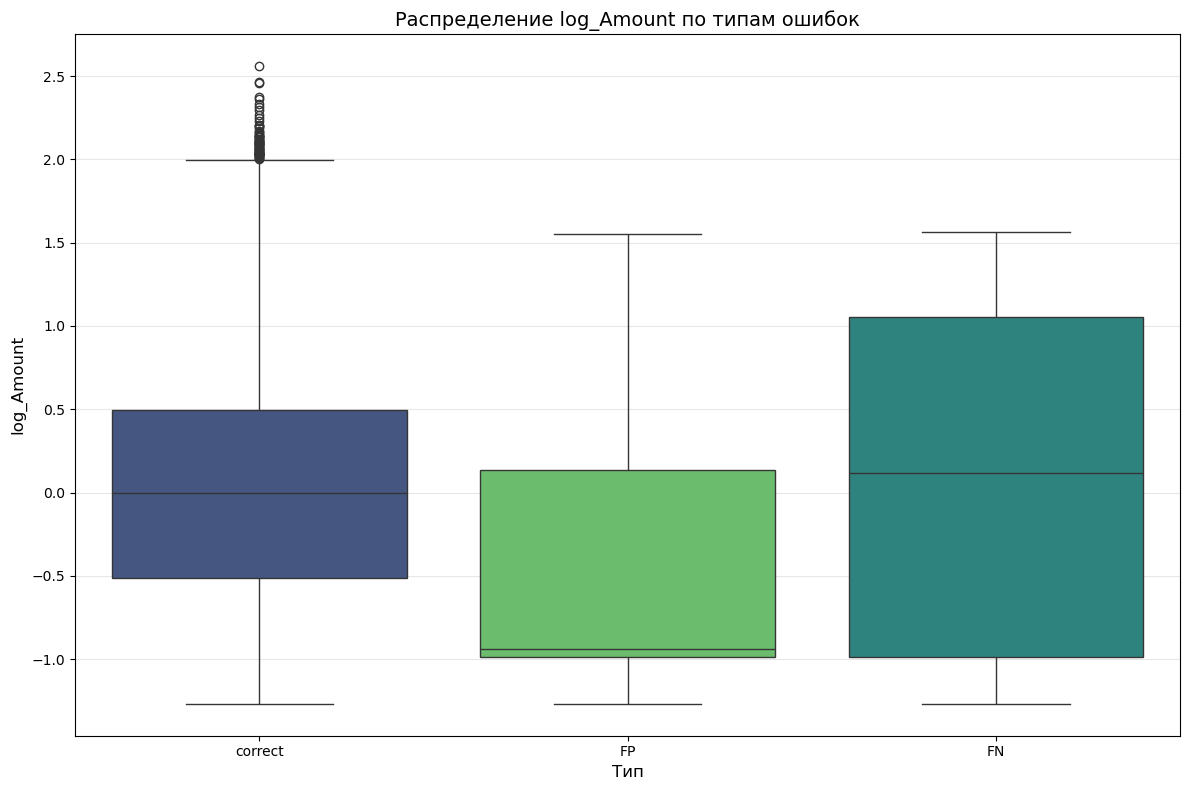

In [88]:
plt.figure(figsize=(12, 8))

sns.boxplot(data=X_test_err, x='error_type', y='log_Amount', 
            order=['correct', 'FP', 'FN'], hue='error_type',
            palette='viridis')

plt.title('Распределение log_Amount по типам ошибок', fontsize=14)
plt.xlabel('Тип', fontsize=12)
plt.ylabel('log_Amount', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

**Анализ распределения ошибок по Time**

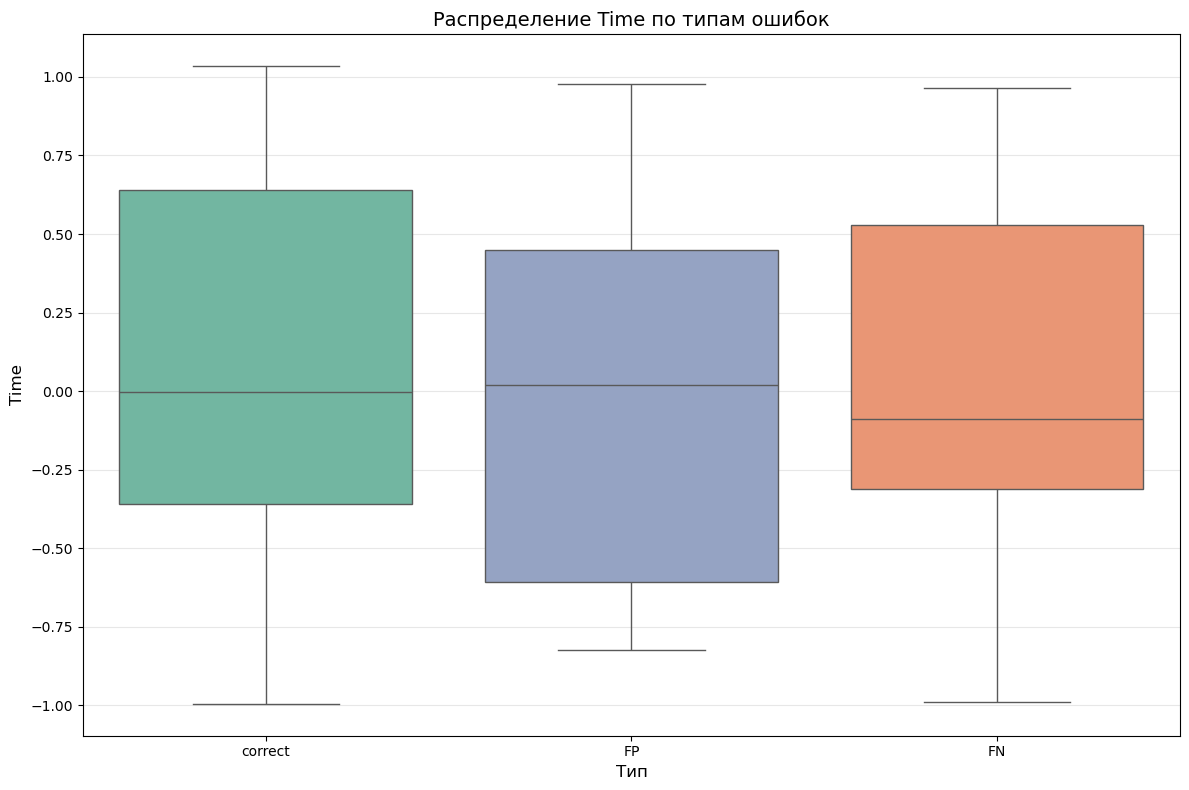

In [89]:
plt.figure(figsize=(12, 8))

sns.boxplot(data=X_test_err, x='error_type', y='Time', 
            order=['correct', 'FP', 'FN'], hue='error_type',
            palette='Set2')

plt.title('Распределение Time по типам ошибок', fontsize=14)
plt.xlabel('Тип', fontsize=12)
plt.ylabel('Time', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

**Гистограммы по типу ошибок**

**log_Amount**

1. **FN (красные)**:

   * сконцентрированы **в области малых и средних значений log_Amount**
   * сильно перекрываются с распределением `correct`

2. **FP (оранжевые)**:

   * чаще встречаются на **краях распределения**
   * заметны выбросы (очень маленькие или очень большие суммы)

3. **Correct (зелёные)**:

   * имеют самое широкое и гладкое распределение
   * покрывают почти весь диапазон значений

---

* **Ложно-отрицательные случаи (FN)** --- это в основном **мошеннические транзакции с небольшими или обычными суммами**, которые находятся в плотных кластерах легальных операций.

* **kNN не может отделить такие FN**, потому что:

  * он основан на локальной близости,
  * а эти транзакции **слишком похожи на нормальные** по сумме.

 **Ключевой вывод по Amount**

> Модель kNN плохо обнаруживает мошенничество, замаскированное под обычные транзакции по сумме операции.

---

**Time**

1. **FN (красные)**:

   * нет ярко выраженной концентрации в отдельных временных зонах

2. **FP (оранжевые)**:

   * чаще появляются:

     * в менее плотных временных регионах,
     * на краях распределения Time

3. **Correct (зелёные)**:

   * образуют чёткую “основную массу” транзакций
   * отражают суточную цикличность

---

* **Время транзакции само по себе не является сильным разделяющим признаком** для kNN:

  * FN происходят в те же часы, что и легальные операции
  * модель не находит локальной аномалии во времени

* FP возникают, когда:

  * транзакция попадает в редкую временную зону,
  * рядом мало соседей → kNN “перестраховывается”

**Ключевой вывод по Time**

> Ошибки модели не имеют чёткой временной локализации --- мошенничество происходит в те же временные интервалы, что и обычные транзакции.

---

#### Почему kNN ошибается

Анализ распределения ошибок показал, что ложные отрицательные случаи (FN) преимущественно соответствуют транзакциям с малыми и средними суммами, происходящими в типичные временные интервалы. Эти операции существенно перекрываются с распределением корректно классифицированных транзакций, что указывает на их высокое сходство с легальным поведением. Алгоритм kNN, основанный на локальной близости объектов, испытывает трудности в обнаружении таких “замаскированных” мошеннических операций, что является его структурным ограничением.

---

#### Итог 

График показывает, что kNN хорошо выявляет аномальные по сумме или времени транзакции, но систематически пропускает мошенничество, которое по ключевым признакам (Amount, Time) неотличимо от нормального поведения, что является ограничением distance-based моделей.

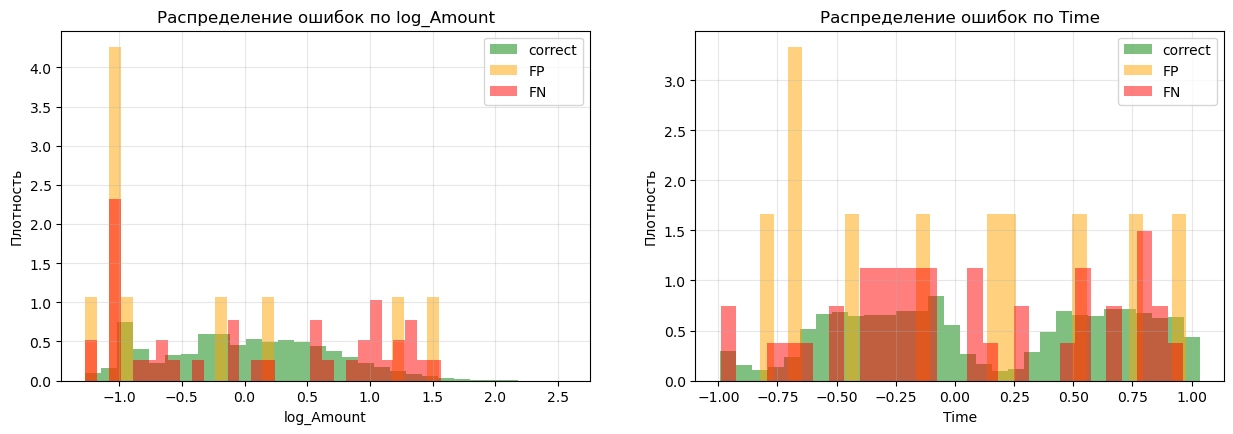

In [95]:
plt.figure(figsize=(15, 10))

if 'log_Amount' in X_test_err.columns and 'Time' in X_test_err.columns:
    plt.subplot(2, 2, 1)
    error_types = ['correct', 'FP', 'FN']
    colors = {'correct': 'green', 'FP': 'orange', 'FN': 'red'}
    
    for err_type in error_types:
        subset = X_test_err[X_test_err['error_type'] == err_type]
        if len(subset) > 0:
            plt.hist(subset['log_Amount'], alpha=0.5, label=err_type, 
                    bins=30, density=True, color=colors.get(err_type, 'blue'))
    
    plt.title('Распределение ошибок по log_Amount')
    plt.xlabel('log_Amount')
    plt.ylabel('Плотность')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 2, 2)
    for err_type in error_types:
        subset = X_test_err[X_test_err['error_type'] == err_type]
        if len(subset) > 0:
            plt.hist(subset['Time'], alpha=0.5, label=err_type, 
                    bins=30, density=True, color=colors.get(err_type, 'blue'))
    
    plt.title('Распределение ошибок по Time')
    plt.xlabel('Time')
    plt.ylabel('Плотность')
    plt.legend()
    plt.grid(True, alpha=0.3)